In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('root')

In [5]:
df_gal_sf4.columns

Index(['run', 'event_number', 'n_lines', 'xz_m1', 'xz_c1', 'xz_m2', 'xz_c2',
       'xz_m3', 'xz_c3', 'yz_m1', 'yz_c1', 'yz_m2', 'yz_c2', 'yz_m3', 'yz_c3',
       'sum_hit_weight_density', 'sum_qdc'],
      dtype='object')

In [2]:
df_all_sf4 = pd.read_parquet("data/recoTri-Run6640-SF4.parquet")
df_gal_sf4 = pd.read_parquet("data/recoTri-Gallery-SF3.parquet")

In [ ]:
def applyCutsToGallery(df,
    sum_hit_density_w_sf = 2500,
    sum_qdc_sf = 200
):
    df = df[df["sum_hit_weight_density"] <= sum_hit_density_w_sf]
    df = df[df["sum_qdc"] <= sum_qdc_sf]
    return df

def get_nonNan(df):
    return df.dropna(subset=["xz_m3", "yz_m3"])

In [4]:
df_all_sf4 = get_nonNan(df_all_sf4)
df_gal_sf4 = applyCutsToGallery(get_nonNan(df_gal_sf4))

KeyError: 'sum_hit_density_w_sf'

In [ ]:
def get_vtx(df):
    df["z_vtx_xz_12"] = (df["xz_c2"] - df["xz_c1"]) / (df["xz_m1"] - df["xz_m2"])
    df["z_vtx_xz_13"] = (df["xz_c3"] - df["xz_c1"]) / (df["xz_m1"] - df["xz_m3"])
    df["z_vtx_xz_23"] = (df["xz_c3"] - df["xz_c2"]) / (df["xz_m2"] - df["xz_m3"])
    df["z_vtx_yz_12"] = (df["yz_c2"] - df["yz_c1"]) / (df["yz_m1"] - df["yz_m2"])
    df["z_vtx_yz_13"] = (df["yz_c3"] - df["yz_c1"]) / (df["yz_m1"] - df["yz_m3"])
    df["z_vtx_yz_23"] = (df["yz_c3"] - df["yz_c2"]) / (df["yz_m2"] - df["yz_m3"])
    return df

df_all_sf4 = get_vtx(df_all_sf4)
df_gal_sf4 = get_vtx(df_gal_sf4)

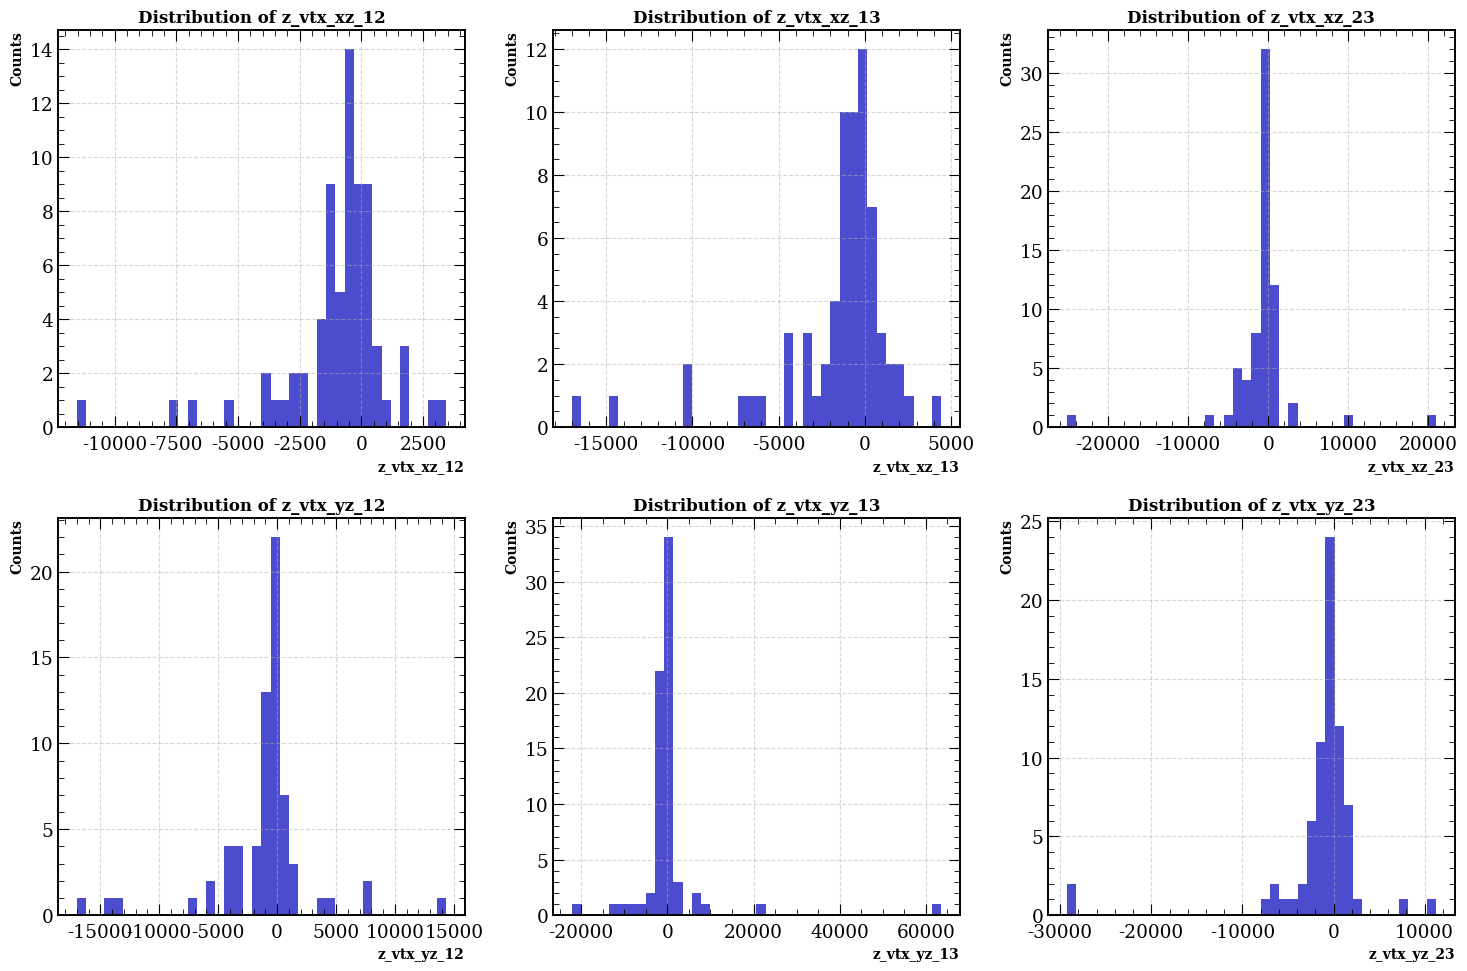

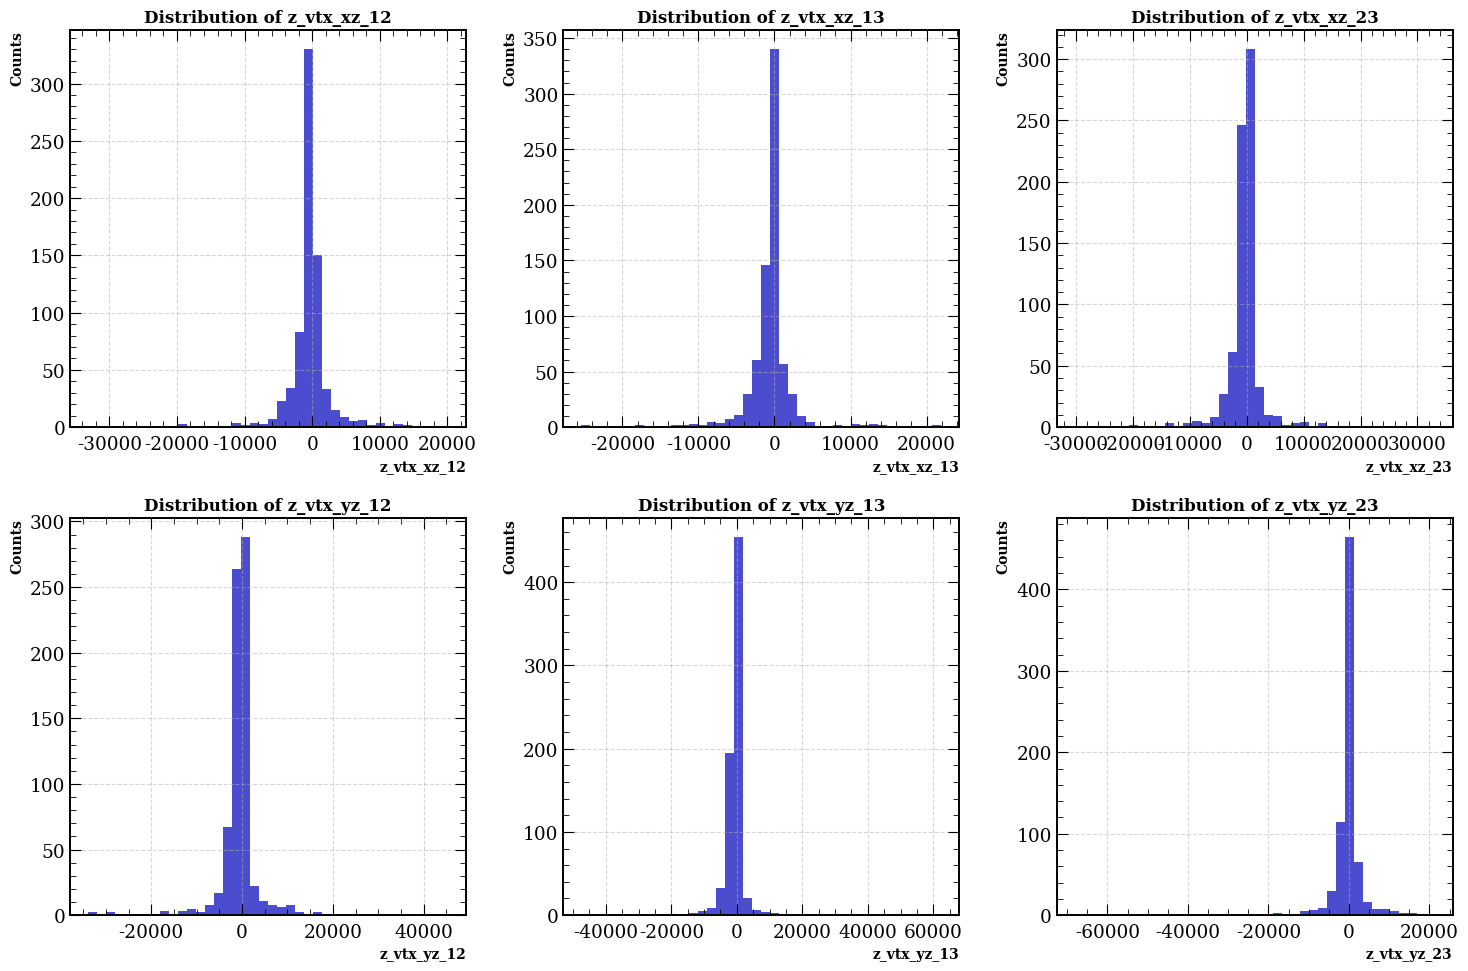

In [ ]:
def plot_cols(df, bins=40, figsize=(15, 10),
    columns_to_plot = [
        "z_vtx_xz_12", "z_vtx_xz_13", "z_vtx_xz_23",
        "z_vtx_yz_12", "z_vtx_yz_13", "z_vtx_yz_23"
    ]
):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(columns_to_plot):
        ax = axes[i]
        
        clean_data = df[col].dropna()
        clean_data = clean_data[~clean_data.isin([float('inf'), float('-inf')])]
        
        ax.hist(clean_data, bins=bins, alpha=0.7)
        
        ax.set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
        ax.set_xlabel(f"{col}", fontsize=10)
        ax.set_ylabel("Counts", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_cols(df_all_sf4)
plot_cols(df_gal_sf4)

In [ ]:
# z_vtx_min = 270
# z_vtx_max = 600

# xz_columns = ["z_vtx_xz_12", "z_vtx_xz_13", "z_vtx_xz_23"]
# yz_columns = ["z_vtx_yz_12", "z_vtx_yz_13", "z_vtx_yz_23"]

# mask = ((df[xz_columns] >= z_vtx_min) & (df[xz_columns] <= z_vtx_max)).any(axis=1)
# df = df[mask]

In [ ]:
print(len(df_all_sf4), len(df_gal_sf4.query("run==6640")))

72 73
